In [13]:
# ==============================
# Day 3 - NLP Text Preprocessing
# ==============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Libraries imported successfully!")


# ==============================
# Download NLTK resources
# ==============================

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

print("NLTK resources downloaded successfully!")


# ==============================
# Load reviews dataset
# ==============================

reviews = pd.read_csv("../data/raw/reviews.csv")

print("Reviews shape:", reviews.shape)
print(reviews.head())


# ==============================
# Create sentiment labels
# ==============================

reviews["sentiment"] = reviews["rating"].apply(
    lambda x: "negative" if x <= 2
    else "neutral" if x == 3
    else "positive"
)

print("\nSentiment distribution:")
print(reviews["sentiment"].value_counts())


# ==============================
# Text preprocessing
# ==============================

# Stop words
stop_words = set(stopwords.words("english"))

# Keep important negation words
important_words = {"not", "no", "never", "nor"}

stop_words = stop_words - important_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stop-word removal
    # 5. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Convert tokens back to text
    return " ".join(tokens)


# Apply preprocessing
reviews["cleaned_text"] = reviews["review_text"].apply(clean_text)


# ==============================
# Check results
# ==============================

print("\nOriginal vs Cleaned Text:")

print(
    reviews[
        ["review_text", "cleaned_text", "sentiment"]
    ].head(10)
)

print("\nMissing values in cleaned_text:")
print(reviews["cleaned_text"].isnull().sum())

Libraries imported successfully!


/home/nineleaps/ML_CAPSTONE_PROJECT/Uber-Eats-ML-Project/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/nineleaps/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt to /home/nineleaps/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


NLTK resources downloaded successfully!
Reviews shape: (43996, 7)
   review_id  order_id  customer_id  restaurant_id  rating  \
0      80001     50001        13068          20124       2   
1      80002     50002        13579          20488       4   
2      80003     50003        12934          20451       5   
3      80004     50004        11504          20078       4   
4      80005     50005        10828          20479       5   

                            review_text     review_timestamp  
0            Food arrived late and cold  2026-06-19 22:50:21  
1   Great restaurant, would order again  2025-09-05 05:42:40  
2  Excellent service and quick delivery  2026-03-13 11:28:32  
3          Very good food and packaging  2026-04-05 21:35:48  
4        The food arrived hot and fresh  2025-12-18 15:38:43  

Sentiment distribution:
sentiment
positive    30843
neutral      7512
negative     5641
Name: count, dtype: int64

Original vs Cleaned Text:
                            review_text  

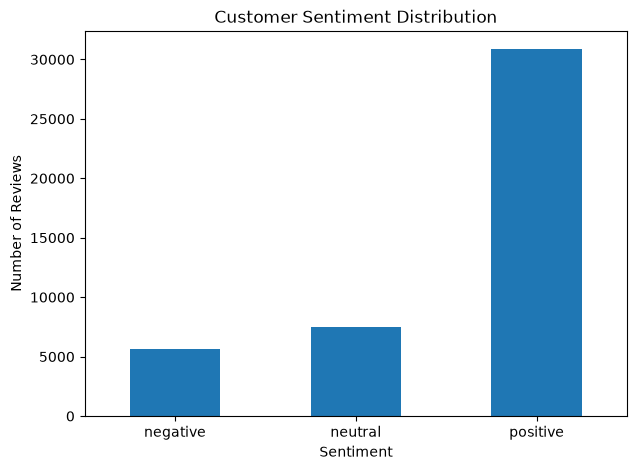

In [14]:
plt.figure(figsize=(7, 5))

reviews["sentiment"].value_counts().reindex(
    ["negative", "neutral", "positive"]
).plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(
    reviews["cleaned_text"]
)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (43996, 100)


In [16]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 100

First 50 features:
['acceptable' 'amazing' 'amazing food' 'arrived' 'arrived hot'
 'arrived late' 'average' 'average experience' 'bad' 'bad experience'
 'cold' 'cold arrived' 'decent' 'delayed' 'delayed significantly'
 'delicious' 'delicious food' 'delivery' 'delivery extremely'
 'delivery good' 'delivery okay' 'disappointing'
 'disappointing experience' 'enjoyed' 'enjoyed meal' 'excellent'
 'excellent service' 'experience' 'experience delicious'
 'experience satisfactory' 'extremely' 'extremely slow' 'fast'
 'fast delivery' 'fine' 'food' 'food arrived' 'food cold' 'food decent'
 'food fast' 'food fresh' 'food not' 'food okay' 'food packaging'
 'food quality' 'fresh' 'fresh tasty' 'good' 'good food' 'good quality']


In [17]:
tfidf_scores = X_tfidf.mean(axis=0).A1

tfidf_words = pd.DataFrame({
    "feature": feature_names,
    "tfidf_score": tfidf_scores
})

tfidf_words = tfidf_words.sort_values(
    "tfidf_score",
    ascending=False
)

tfidf_words.head(20)

,feature,tfidf_score
35,food,0.105910
17,delivery,0.066767
68,order,0.064626
45,fresh,0.056178
47,good,0.051640
27,experience,0.050856
33,fast delivery,0.047302
32,fast,0.047302
50,great,0.047275
89,satisfied order,0.042364


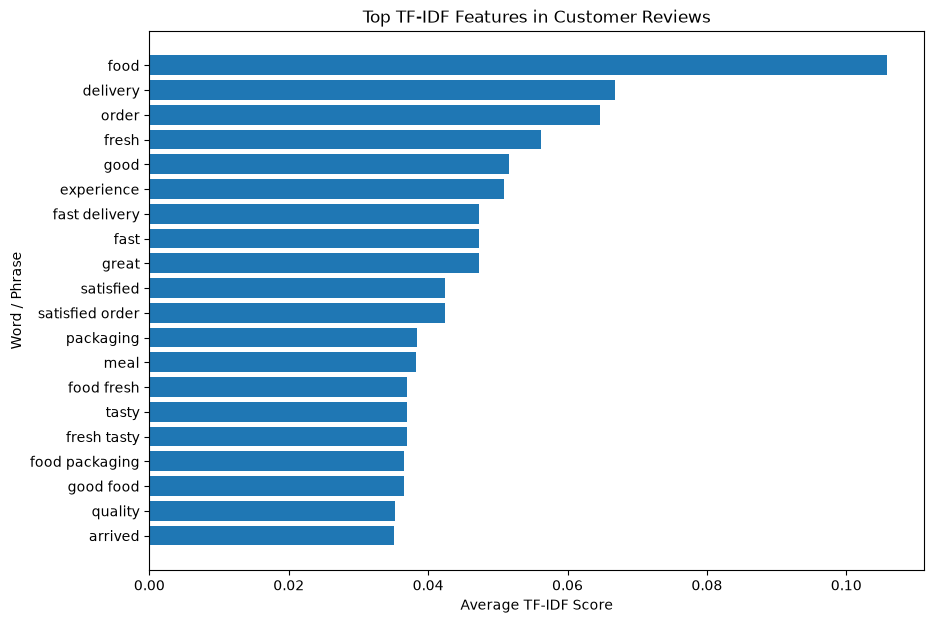

In [18]:
top_features = tfidf_words.head(20).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["tfidf_score"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word / Phrase")
plt.title("Top TF-IDF Features in Customer Reviews")
plt.show()

In [19]:
# Calculate TF-IDF separately for positive and negative reviews

positive_reviews = reviews[
    reviews["sentiment"] == "positive"
]["cleaned_text"]

negative_reviews = reviews[
    reviews["sentiment"] == "negative"
]["cleaned_text"]


# Positive TF-IDF
positive_tfidf = tfidf_vectorizer.transform(positive_reviews)

positive_scores = positive_tfidf.mean(axis=0).A1

positive_features = pd.DataFrame({
    "feature": feature_names,
    "tfidf_score": positive_scores
}).sort_values(
    "tfidf_score",
    ascending=False
)


# Negative TF-IDF
negative_tfidf = tfidf_vectorizer.transform(negative_reviews)

negative_scores = negative_tfidf.mean(axis=0).A1

negative_features = pd.DataFrame({
    "feature": feature_names,
    "tfidf_score": negative_scores
}).sort_values(
    "tfidf_score",
    ascending=False
)


print("Top Positive Features:")
display(positive_features.head(20))

print("\nTop Negative Features:")
display(negative_features.head(20))

Top Positive Features:


,feature,tfidf_score
35,food,0.123436
17,delivery,0.082045
45,fresh,0.074432
68,order,0.073820
47,good,0.073661
33,fast delivery,0.067474
32,fast,0.067474
50,great,0.067435
88,satisfied,0.060430
89,satisfied order,0.060430



Top Negative Features:


,feature,tfidf_score
60,not,0.127330
10,cold,0.088176
75,poor,0.086476
35,food,0.066740
22,disappointing experience,0.066446
21,disappointing,0.066446
3,arrived,0.063344
27,experience,0.058738
41,food not,0.058130
61,not fresh,0.058130


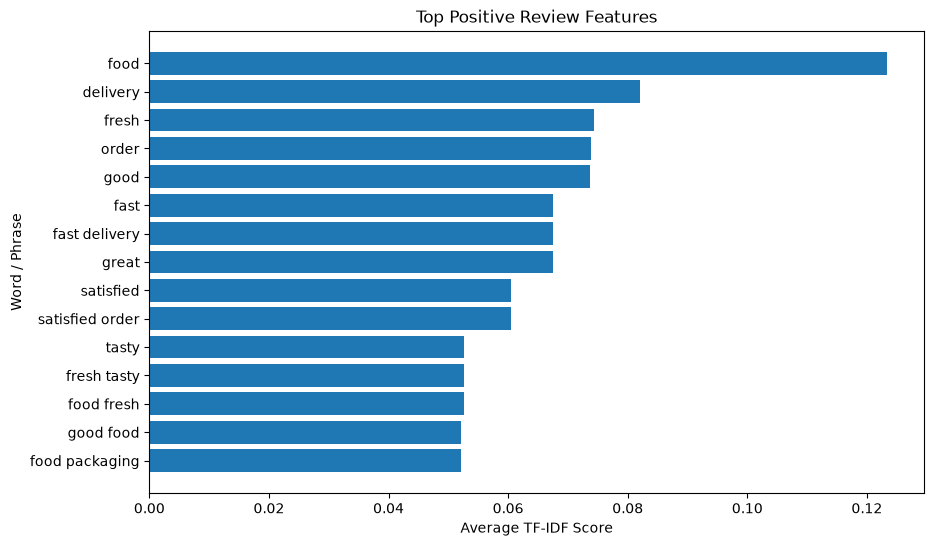

In [20]:
top_positive = positive_features.head(15).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive["feature"],
    top_positive["tfidf_score"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word / Phrase")
plt.title("Top Positive Review Features")

plt.show()

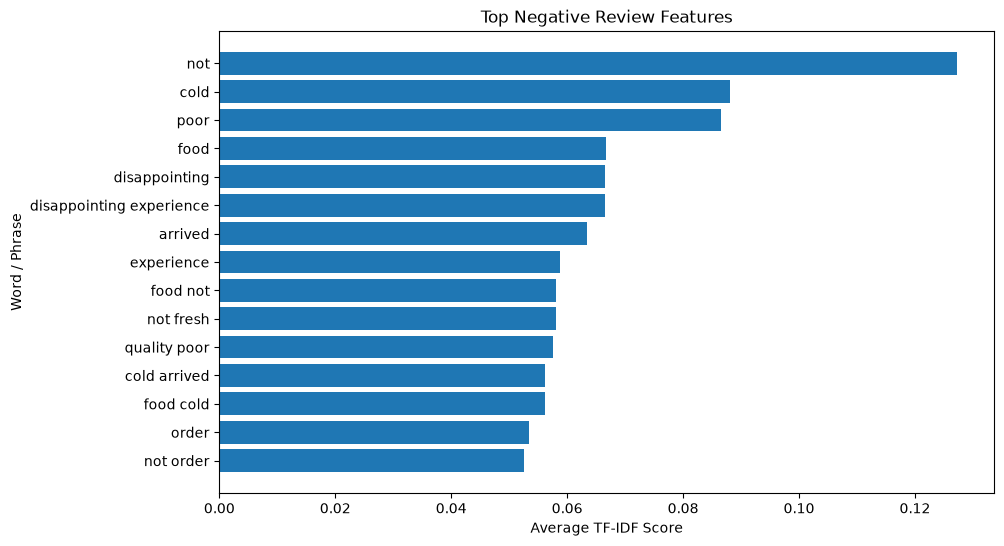

In [21]:
top_negative = negative_features.head(15).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative["feature"],
    top_negative["tfidf_score"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word / Phrase")
plt.title("Top Negative Review Features")

plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    reviews["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=reviews["sentiment"]
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (35196, 100)
Testing data: (8800, 100)


In [23]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [24]:
y_pred = nb_model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
['positive' 'neutral' 'neutral' 'positive' 'positive' 'negative'
 'positive' 'positive' 'positive' 'neutral' 'neutral' 'positive'
 'positive' 'negative' 'positive' 'negative' 'positive' 'positive'
 'positive' 'neutral']


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1128
     neutral       1.00      1.00      1.00      1503
    positive       1.00      1.00      1.00      6169

    accuracy                           1.00      8800
   macro avg       1.00      1.00      1.00      8800
weighted avg       1.00      1.00      1.00      8800



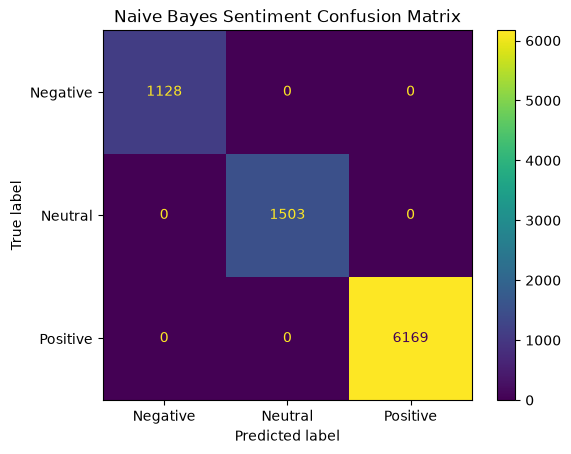

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()

plt.title("Naive Bayes Sentiment Confusion Matrix")
plt.show()

Naive Bayes achieved 100% accuracy, precision, recall, and F1-score on the test set. The perfect performance is likely influenced by the strong relationship between the rating-derived sentiment labels and the review text patterns in the dataset. Therefore, the result demonstrates successful classification on this dataset but should not be assumed to generalize to real-world customer reviews.

In [27]:
import nltk

nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("VADER loaded successfully!")

/home/nineleaps/ML_CAPSTONE_PROJECT/Uber-Eats-ML-Project/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/nineleaps/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/nineleaps/nltk_data...


VADER loaded successfully!


In [28]:
reviews["vader_score"] = reviews["review_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

print(reviews[
    ["review_text", "rating", "sentiment", "vader_score"]
].head(10))

                            review_text  rating sentiment  vader_score
0            Food arrived late and cold       2  negative       0.0000
1   Great restaurant, would order again       4  positive       0.6249
2  Excellent service and quick delivery       5  positive       0.5719
3          Very good food and packaging       4  positive       0.4927
4        The food arrived hot and fresh       5  positive       0.3182
5              Food was fresh and tasty       5  positive       0.3182
6        Nothing special but acceptable       3   neutral      -0.4717
7         Very disappointing experience       2  negative      -0.5413
8   Fast delivery and good quality food       5  positive       0.4404
9          Very satisfied with my order       4  positive       0.4754


In [29]:
def vader_sentiment(score):

    if score >= 0.05:
        return "positive"

    elif score <= -0.05:
        return "negative"

    else:
        return "neutral"


reviews["vader_sentiment"] = reviews["vader_score"].apply(
    vader_sentiment
)

print(reviews["vader_sentiment"].value_counts())

vader_sentiment
positive    34668
neutral      5143
negative     4185
Name: count, dtype: int64


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

vader_accuracy = accuracy_score(
    reviews["sentiment"],
    reviews["vader_sentiment"]
)

vader_precision = precision_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_recall = recall_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_f1 = f1_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

print(f"VADER Accuracy : {vader_accuracy:.4f}")
print(f"VADER Precision: {vader_precision:.4f}")
print(f"VADER Recall   : {vader_recall:.4f}")
print(f"VADER F1-score : {vader_f1:.4f}")

print("\nVADER Classification Report:")
print(
    classification_report(
        reviews["sentiment"],
        reviews["vader_sentiment"]
    )
)

VADER Accuracy : 0.8450
VADER Precision: 0.8252
VADER Recall   : 0.8450
VADER F1-score : 0.8279

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.61      0.70      5641
     neutral       0.57      0.39      0.46      7512
    positive       0.89      1.00      0.94     30843

    accuracy                           0.84     43996
   macro avg       0.76      0.66      0.70     43996
weighted avg       0.83      0.84      0.83     43996



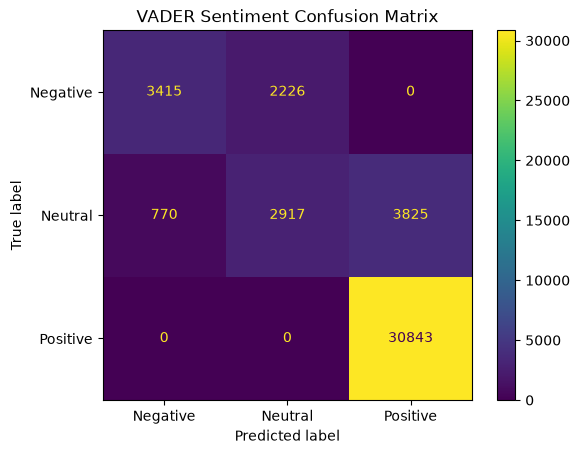

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_vader = confusion_matrix(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    labels=["negative", "neutral", "positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_vader,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()

plt.title("VADER Sentiment Confusion Matrix")
plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert review text to lowercase
text = reviews["review_text"].str.lower()

# Count reviews containing each complaint theme
complaint_counts = {
    "Food Quality": text.str.contains(
        r"cold|not fresh|quality poor|food cold",
        regex=True
    ).sum(),

    "Delivery Delays": text.str.contains(
        r"delayed|order delayed|arrived late|late",
        regex=True
    ).sum(),

    "Poor Experience": text.str.contains(
        r"poor|disappointing",
        regex=True
    ).sum(),

    "Packaging Issues": text.str.contains(
        r"packaging|package",
        regex=True
    ).sum()
}

complaint_df = (
    pd.DataFrame(
        list(complaint_counts.items()),
        columns=["Complaint Theme", "Review Count"]
    )
    .sort_values("Review Count", ascending=False)
)

print(complaint_df)

    Complaint Theme  Review Count
3  Packaging Issues          3679
0      Food Quality          1690
2   Poor Experience          1676
1   Delivery Delays          1158


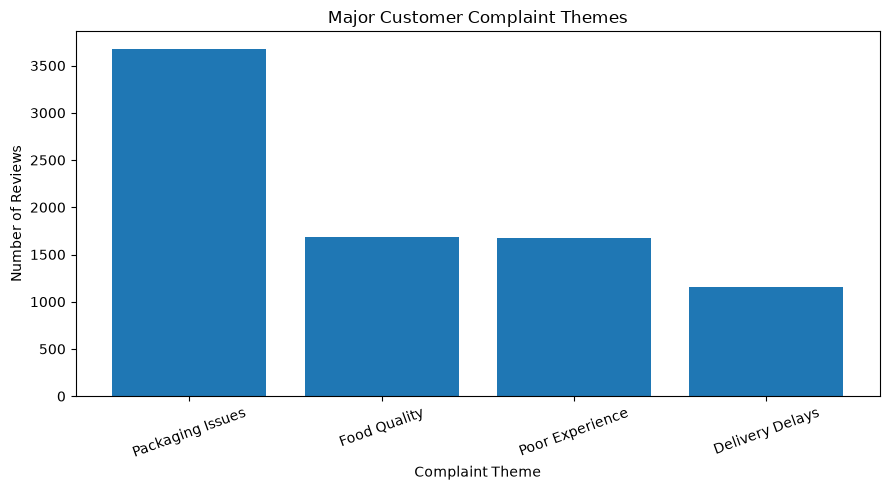

In [33]:
plt.figure(figsize=(9, 5))

plt.bar(
    complaint_df["Complaint Theme"],
    complaint_df["Review Count"]
)

plt.title("Major Customer Complaint Themes")
plt.xlabel("Complaint Theme")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

BERT